# Student Identification & Submission Details

Please complete the following information before submitting your notebook.

**UNI:**  mhs2229, sz3388, lj2496

**Full Name:**  Maisy Song, Siyi Zhou, Leo Jergovic

**Public GitHub Repository URL (Final Project Report & Code):** https://github.com/thefleok/QMSSGR5074_Project1/tree/main

---

## Submission Requirements

- The GitHub repository **must be public**.
- The repository should include:
  - A complete and well-formatted final report
  - Clean, well-documented source code
  - Clear instructions for reproducing results (if applicable)
- Verify that all links are functional and accessible prior to submission.

# Project Submission Guidelines

### Submission Due Date: March 9, 2026

Throughout this notebook, you will encounter the keyword **`TODO`** in multiple sections. Each `TODO` indicates a required component that must be completed by you.

These may include:

- Implementing missing code
- Specifying or tuning model parameters
- Writing explanations and technical reasoning
- Performing analysis and interpreting results
- Justifying modeling decisions
- Completing evaluation procedures

---

## Expectations

You are expected to:

- Replace **every** `TODO` with correct, fully functional code.
- Provide complete, clear, and technically sound explanations where required.
- Justify modeling choices using appropriate reasoning and evidence.
- Ensure the notebook executes from start to finish **without errors**.

> **Note:** Any section that still contains `TODO` at the time of submission will be considered **incomplete**.

# World Happiness Classification Competition

## Project Objectives

This competition is designed to help you:

- Develop a deep understanding of how machine learning models function
- Understand the role and impact of model hyperparameters
- Learn from systematic experimentation and model iteration
- Produce a professional, well-structured notebook report
- Publish the final project as a portfolio-ready GitHub repository

---

## Project Workflow

You will complete the project through the following stages:

1. **Load and Merge Datasets**  
   - Import all relevant datasets  
   - Perform necessary joins and validation  

2. **Data Preprocessing**  
   - Build preprocessing pipelines using `sklearn`'s `ColumnTransformer`  
   - Handle missing values, encoding, scaling, and feature engineering  

3. **Model Training**  
   - Fit the model using the processed data  
   - Save both the preprocessing pipeline and trained model  

4. **Prediction and Evaluation**  
   - Generate predictions  
   - Evaluate performance using appropriate metrics  

5. **Hyperparameter Tuning**  
   - Systematically tune model parameters  
   - Compare performance across configurations  

6. **Deep Learning Experimentation**  
   - Implement and evaluate a neural network approach  
   - Compare results with classical ML models  

7. **Model Explainability (SHAP)**  
   - Apply SHAP for feature importance analysis  
   - Interpret and explain model decisions  

8. **Final Report Submission**  
   - Clean and organize the notebook  
   - Ensure full reproducibility  
   - Upload the final report and code to a public GitHub repository  

---

## 0. Loading Datasets

In this section, we load the **World Happiness 2023** datasets that will be used throughout the project.

**Objectives of this stage:**

- Import the datasets into the notebook environment
- Inspect their structure and contents
- Verify column names and data types
- Identify potential inconsistencies before merging

> Careful dataset inspection at this stage prevents downstream errors and ensures a clean modeling pipeline.

In [143]:
# LEO: We add this cell to consistently import our data using Google Drive.

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **YOU MUST PUT BOTH CSV FILES IN YOUR HOME "MY DRIVE" FOLDER IN GOOGLE DRIVE IN ORDER FOR THE NEXT STEP TO WORK**

In [144]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
whr_df = pd.read_csv('/content/drive/MyDrive/WHR_2023.csv') # this file path corresponds to the My Drive home of our google drive

# Inspect the first few rows to understand the structure
whr_df.head() # modified by LEO to save space. We still inspect a few rows with head but avoid last few rows


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394


In [145]:
# Convert the regression target ('happiness_score') into classification labels
# We'll use quartiles to create 4 happiness categories: Very Low, Low, High, Very High

# Define quartiles
whr_df['happiness_category'] = pd.qcut(whr_df['happiness_score'],
                                       q=5,
                                       labels=['Very Low', 'Low','Average', 'High', 'Very High'])

# Select features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert y_train and y_test to numerical labels
y_train_labels = y_train.astype('category').cat.codes
# y_test_labels = ## Complete in a similar manner as above. TODO

In [146]:
# LEO:
y_test_labels = y_test.astype('category').cat.codes # we convert y_test into numerical labels
y_test_labels.head() # check that this action worked by displaying

,0
43,3
37,3
117,0
96,1
75,2


### Conceptual Question

In the next cell, briefly explain the following:

1. What does `y_train.astype('category').cat.codes` do?
2. What is the difference between `y_train_labels` and `y_train`?

Keep your explanation clear and concise.

*Replace this section with your response.*

**LEO:**

[Answer 1] The code snippet *y_train.astype('category').cat.codes* is implemented because we begin by dividing our *happiness_category* variable into what the code comments describe as 4 quartiles, but what the actual implementation divides into 5 "quartiles" — Very Low, Low, Average, High, Very High. The code can be seen in three phases within the line. In phase 1, the *.astype('category')* portion classifies our variable as categorical (for our 5 classifications that we assigned). The *.cat.* portion is the second phase, which is a necessary portion to append in order to perform categorical operations through pandas. Our *.codes* portion finally assigns numerical codes here.

[Answer 2] Let us simply visualize the difference:

In [147]:
y_train_labels.head(1)

,0
126,0


In [148]:
y_train.head(1)

,happiness_category
126,Very Low


As we can see, the difference between *y_train_labels* and *y_train* is fundamentally the **dtype** listed at the bottom. While *y_train* is a category-oriented variable ("Low," "Very Low," etc.), *y_train_labels* is a integer-oriented variable.

### Add New Data

In [149]:
# Truncated and cleaned up region data to merge
countrydata=pd.read_csv("/content/drive/MyDrive/newcountryvars.csv") # LEO: modified to include the MyDrive default space for imports in colab

countrydata.head()

,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,India,1339180127,21.9,0.623559,68.322,11.696590,6.298834,5663.474799
1,Nigeria,190886311,70.0,0.527105,53.057,9.970482,6.000000,5442.901264
2,Mexico,129163276,46.2,0.761683,76.972,13.299090,8.554985,16383.106680
3,Pakistan,197015955,29.5,0.550354,66.365,8.106910,5.089460,5031.173074
4,Bangladesh,164669751,31.5,0.578824,71.985,10.178706,5.241577,3341.490722


In [150]:
# Merge in new data to X_train and X_test by taking "country" from first table and "country_name" from 2nd table.
# Also check which countries are common in both the datasets, and which type of merge will you perform for the best results.
# Hint: Look on the 'how' parameter of megre function of pandas.

## X_train = ## Complete code TODO
## X_test = ## Complete code TODO

# LEO: Code solution follows

In [151]:
# LEO: Finding X_train
# First we want to inspect what countries are common between our X_train/X_test and our countrydata df
x__train_countries = set(X_train['country']) # make a set of all unique countries in X_train
countrydata_countries = set(countrydata['country_name']) # make a set of all unique countries in countrydata

# determine shared countries between them
shared_countries = x__train_countries.intersection(countrydata_countries)
len(shared_countries)

89

In [152]:
#LEO: Finding X_train
# How many unique countries actually exist in X_train?
X_train['country'].nunique()

95

In [153]:
# LEO: Finding X_train
# We merge our datasets using how = "left" to preserve all existing X_train rows
X_train = X_train.merge(countrydata, left_on= "country", right_on = "country_name", how = "left")
len(X_train)

95

In [154]:
# LEO: Finding X_test
# First we want to inspect what countries are common between our X_train/X_test and our countrydata df
x_test_countries = set(X_test['country']) # make a set of all unique countries in X_test

# determine shared countries between them
shared_countries_test = x_test_countries.intersection(countrydata_countries)
len(shared_countries_test)

39

In [155]:
# LEO: Finding X_test
# perform a similar merge
X_test = X_test.merge(countrydata, left_on= "country", right_on = "country_name", how = "left")
len(X_test)

42

---

## 1. Exploratory Data Analysis and Visualization (EDAV)

In [156]:
print(X_train.dtypes)

country                           object
region                            object
gdp_per_capita                   float64
social_support                   float64
healthy_life_expectancy          float64
freedom_to_make_life_choices     float64
generosity                       float64
perceptions_of_corruption        float64
country_name                      object
population                       float64
population_below_poverty_line    float64
hdi                              float64
life_expectancy                  float64
expected_years_of_schooling      float64
mean_years_of_schooling          float64
gni                              float64
dtype: object


### Describe What You Observe

*Replace this section with your response.*

**LEO**: Couple of observations. The first observation is that the majority of our variables are float variables, with the exception of country_name, region, and country (2 of which are redundant). This is actually to our benefit because it allows us to use (majoratively) quantitative regions in our analysis.

The second observation is that there are a few variables that may overlap or provide similar insights about the populations we are studying. gdp_per_capita and population_below_poverty_line for instance, provide similar information about the level of poverty in a country. Expected and mean years of schooling, though we may not have detailed insight, likely provide similar figures (at least on a correlational basis). These will be factors we need to consider in our analysis/if presented with opportunities to shrink the dataset.

### Missing Values Analysis

Compute the number and percentage of missing values for each column and present the results in a clear summary table.

In [157]:
# LEO: X_train Missing Values
nan_train = X_train.isnull().sum() # our nan gives ut the number of null values for each variable
nan_percent_train = (nan_train /len(X_train))*100  # we simply want the percentage of missing values for each rather than the pure magnitude
nan_table_train = pd.DataFrame({"Percentage of NAN Xtrain Values": nan_percent_train.round(1)}).sort_values("Percentage of NAN Xtrain Values")

nan_table_train

,Percentage of NAN Xtrain Values
country,0.0
region,0.0
gdp_per_capita,0.0
social_support,0.0
healthy_life_expectancy,0.0
freedom_to_make_life_choices,0.0
generosity,0.0
perceptions_of_corruption,0.0
country_name,6.3
population,6.3


In [158]:
# LEO: X_test Missing Values
nan_test = X_test.isnull().sum() # our nan gives ut the number of null values for each variable
nan_percent_test = (nan_test /len(X_test))*100  # we simply want the percentage of missing values for each rather than the pure magnitude
nan_table_test = pd.DataFrame({"Percentage of NAN Xtest Values": nan_percent_test.round(1)}).sort_values("Percentage of NAN Xtest Values")

nan_table_test

,Percentage of NAN Xtest Values
country,0.0
region,0.0
gdp_per_capita,0.0
social_support,0.0
freedom_to_make_life_choices,0.0
generosity,0.0
perceptions_of_corruption,0.0
healthy_life_expectancy,2.4
country_name,7.1
population,7.1


### Distribution of Key Numerical Features

Select relevant numerical features and plot their histograms. Choose features that may influence the target variable, and briefly comment on notable patterns, skewness, or outliers.

In [159]:
# LEO: import matplotlib so that we can graph our charts
import matplotlib.pyplot as plt

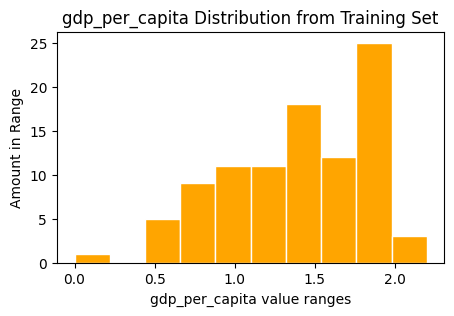

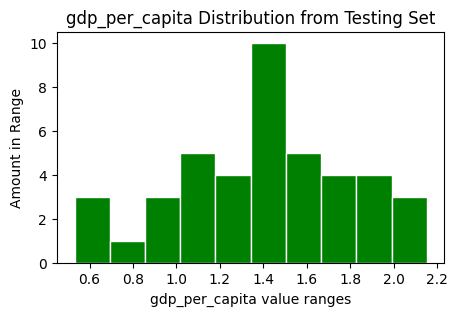

In [160]:
# LEO: we start by creating a function that plots histograms for any desired variable in our training/test data.
# We estimate that gdp per capita likely has an impact on happiness (from our macroeconomics undergrad courses)
def plot_histogram(source, variable):
  plt.figure(figsize=(5, 3))
  if source == "train":
    plt.hist(X_train[variable].dropna(), bins=10, color='orange', edgecolor="white")
    plt.title(f'{variable} Distribution from Training Set')
  if source == "test":
    plt.hist(X_test[variable].dropna(), bins=10, color='green', edgecolor="white")
    plt.title(f'{variable} Distribution from Testing Set')
  plt.xlabel(f'{variable} value ranges')
  plt.ylabel('Amount in Range')
  plt.show()

# We are interested in training and testing for gdp per capita (potentially related to happiness based on macroeconomic theory)
plot_histogram("train",'gdp_per_capita')
plot_histogram("test",'gdp_per_capita')




**LEO**: [Brief commentary] We can see that relative value ranges are pretty consistent across training and test data for the gdp per capita, but there is a slightly higher prevalence of high gdp per capita countries in the training data (a so called right skew). Given that there is an outlier value in the training data on the low end, this likely excacerbates the visual identity of this discrepancy. In the testing data, an outlier emerges around the value of 1.4 for GDP per capita.

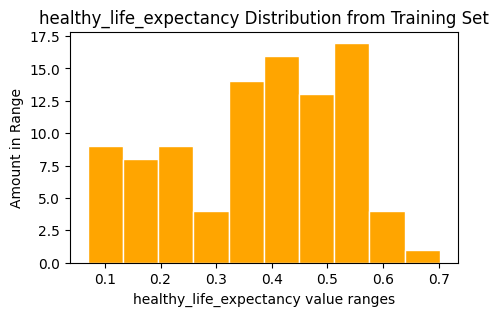

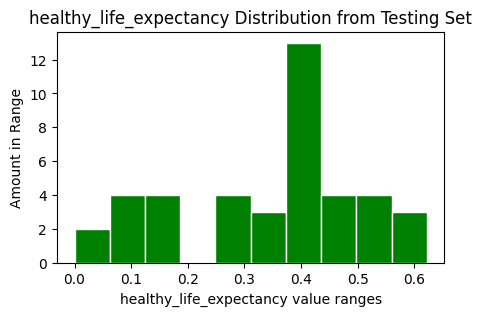

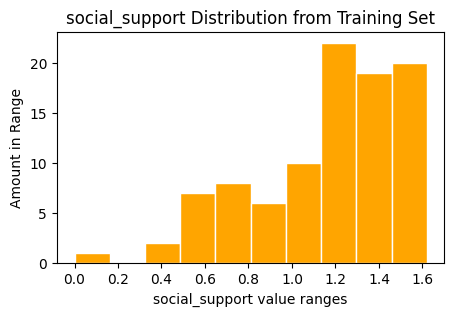

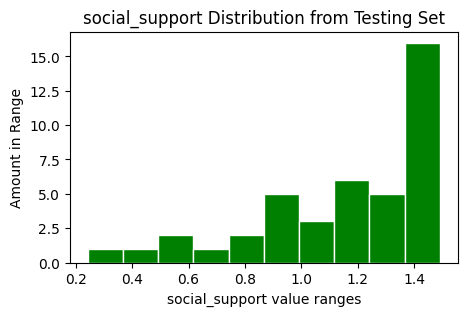

In [161]:
# We are also curious for healthy_life_expectancy and social_support
plot_histogram("train",'healthy_life_expectancy')
plot_histogram("test",'healthy_life_expectancy')
plot_histogram("train",'social_support')
plot_histogram("test",'social_support')

**LEO**: [Brief Discussion] We see additional numerical discrepancies between our different charts of training and testing data. Social support skews to the higher end, with similar distributions across both sets. However, healthy_life_expectancy has an outlier in the training set that is not present in the testing data. This is also quite possibly related to a smaller amount of samples in the testing data, so the full distribution is potentially not captured. The outlier is around 0.4 for the training data.

### Distribution of Categorical Variables

Plot the distribution of relevant categorical variables using appropriate visualizations (e.g., count plots or bar charts). Briefly comment on class imbalance or notable patterns.

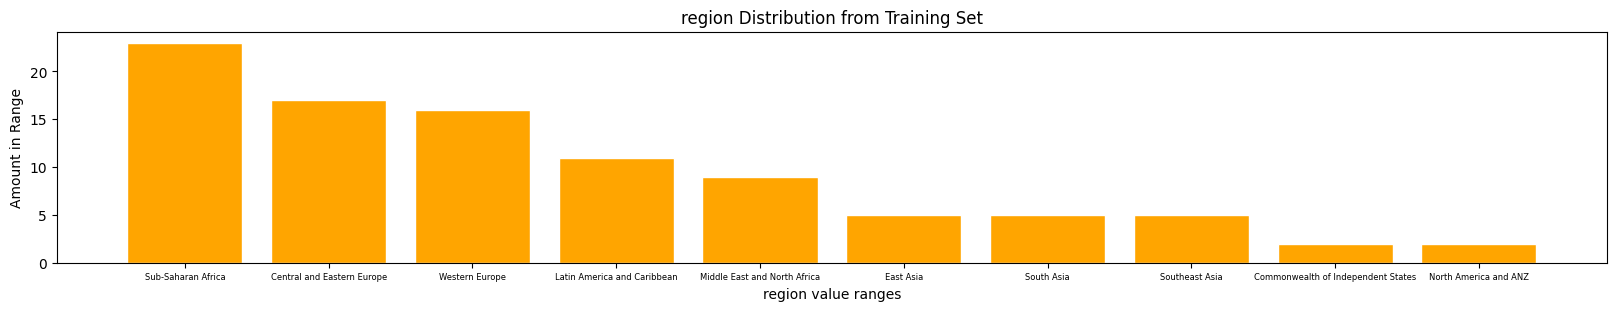

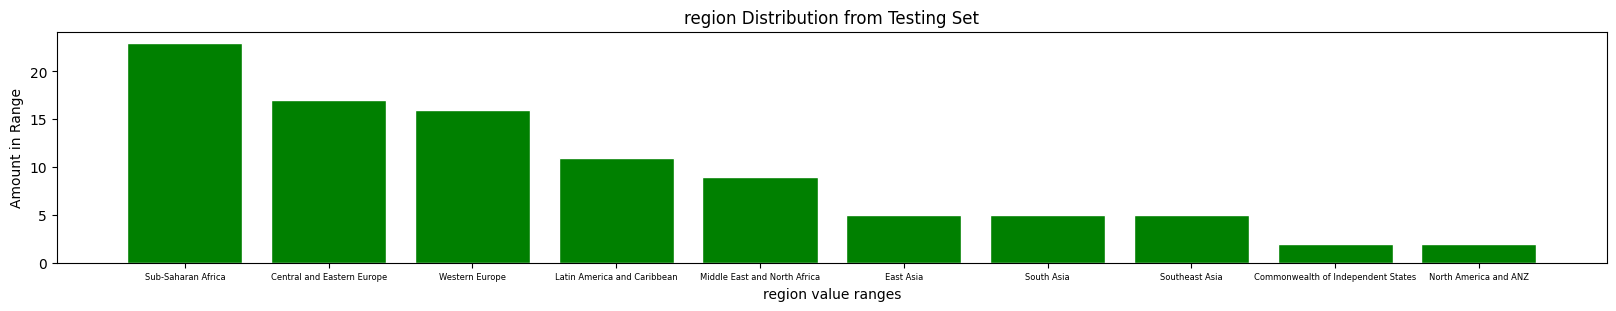

In [162]:
# Your plotting code here: TODO
# LEO: Our only categorical variable is the region of the countries (with the exception of country name)
# We need to redo the code for this plot because a categorical plot is slightly different
def plot_bar(source, variable):
  plt.figure(figsize=(20, 3))
  count = X_train[variable].value_counts()
  if source == "train":
    plt.bar(count.index, count.values, color='orange', edgecolor='white')
    plt.title(f'{variable} Distribution from Training Set')
  if source == "test":
    plt.bar(count.index, count.values, color='green', edgecolor='white')
    plt.title(f'{variable} Distribution from Testing Set')
  plt.xticks(fontsize=6) # added to make the categories fit
  plt.xlabel(f'{variable} value ranges')
  plt.ylabel('Amount in Range')
  plt.show()

plot_bar("train","region")
plot_bar("test","region")


The regional distributions look pretty identical, with a skew for sub-saharan and central/eastern european countries. This is partially because there are simply less countries in areas like north America or Southeast Asia than the entire central/eastern european region (where the same area can be encompassed by just the US). However, it may make predictions potentially more accurate for certain regions over others.

### Feature Correlation Analysis

Analyze the relationships between numerical features using correlation coefficients. Compute and visualize:

- **Pearson correlation** — linear relationships
- **Spearman correlation** — monotonic relationships
- **Kendall correlation** — rank-based relationships

Use correlation matrices and heatmaps where appropriate. Briefly interpret strong positive or negative correlations and discuss potential multicollinearity.

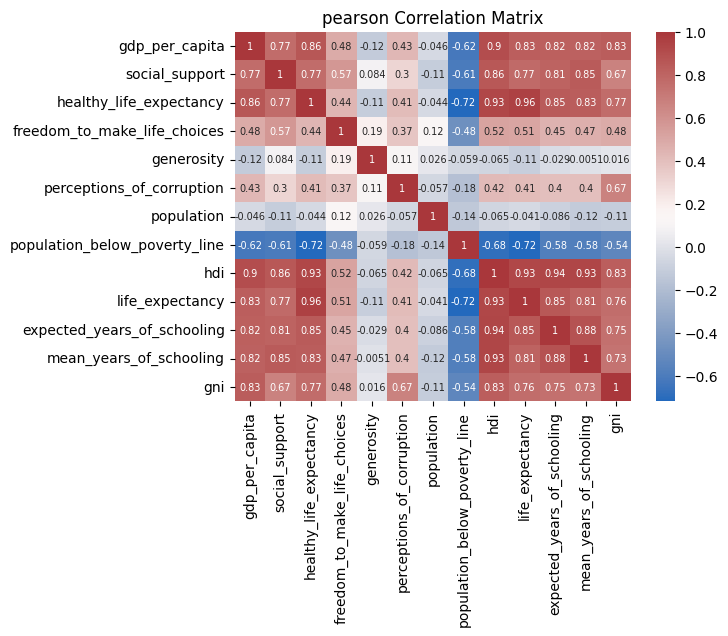

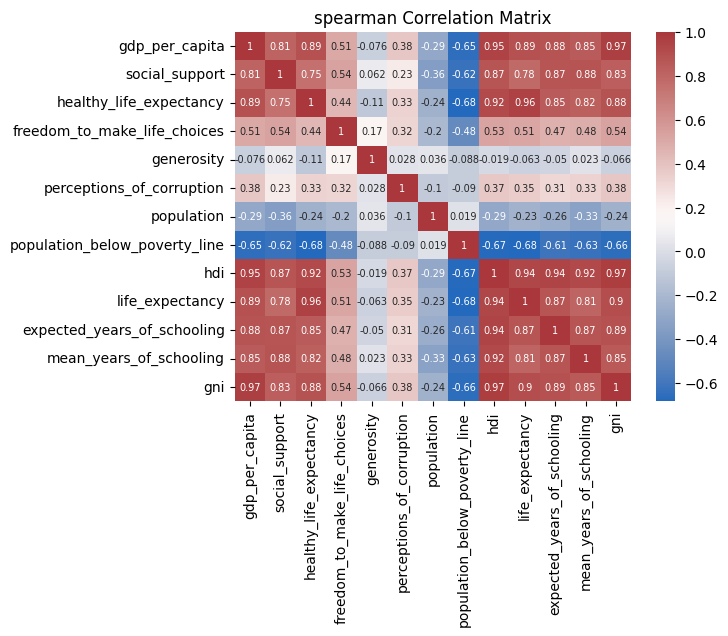

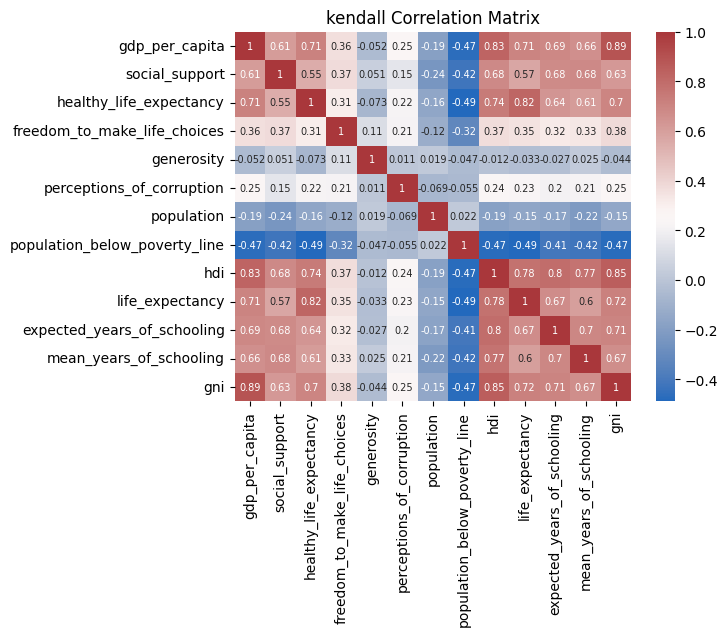

In [163]:
# Your code here: TODO
# LEO: we functionalize matrix creation using seaborn
import seaborn as sns
numerical_features_train = X_train.select_dtypes(include="number").columns # we only include numeric features for correlation matrices

# use plot_matrix to functionalize this process and not repeat
def plot_matrix (method):
  matrix = X_train[numerical_features_train].corr(method=method)
  sns.heatmap(matrix, annot=True, cmap='vlag',annot_kws={'size': 7}) # we use matrix, annot for values, cmap for color specification, and annot to reduce text size
  plt.title(f'{method} Correlation Matrix')
  plt.show()

plot_matrix("pearson")
plot_matrix("spearman")
plot_matrix("kendall")

**LEO**: [Brief Commentary] We clearly observe that along the diagonal line, correlations tend to be a perfect "1." This is because variables are perfectly correlated with themselves.

Outside of this, we notice a few things. First and foremost, hdi exhibits high correlation with expected years of schooling on multiple correlation matrices. This is because HDI is a combined weighted index of "Life expectancy," "Education," and "Standard of Living." Interestingly enough, the HDI—GNI relationship is higher on the kendall correlation than the hdi—life expectancy correlation, while it is lower on the pearson correlation. This indicates that it may have a lower raw linear correlation, but more rank-based multicollinearity.

Another factor that has high kendall/spearman and slightly lower (but high) spearman is the gni/gdp per capita relationship. This makes sense given that GNI is a measure of gross national income, so should be roughly on terms with GDP per capita (though GDP includes other factors like government expenditure, trade, etc.).

In terms of low correlation, population and generosity seem to be almost universally barely related to other variables. On all 3 correlation matrices, they hover close to 0 (the pale blue coloration that can be visualized in each).

Population below the poverty line, on the other hand, exhibits the strongest negative correlation across the map, which makes sense — as population below the poverty line increases, gdp per capita, gni, and other factors that are inversely related to poverty seem to go down.

### Bivariate Analysis and Relationship Exploration

Explore relationships between features and examine how they associate with the target variable. Include:

- Bivariate plots (e.g., scatter plots, box plots, grouped bar charts)
- Correlation tables
- Comparisons of feature distributions across target classes

Briefly summarize key relationships and any patterns that may influence model performance.

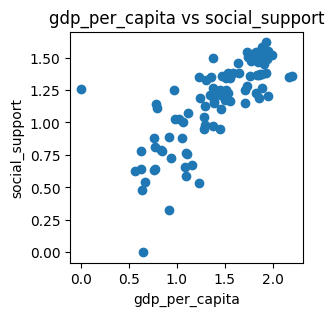

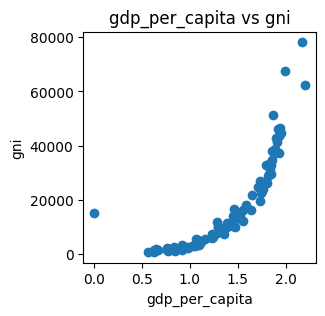

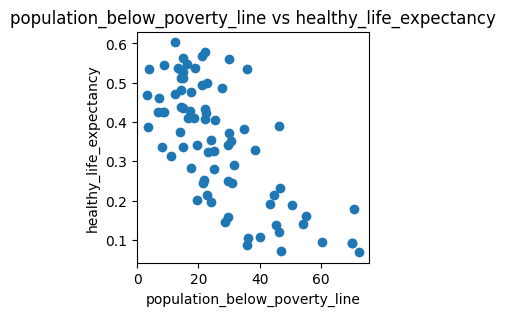

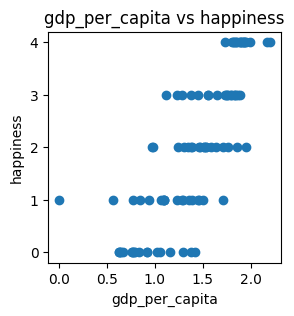

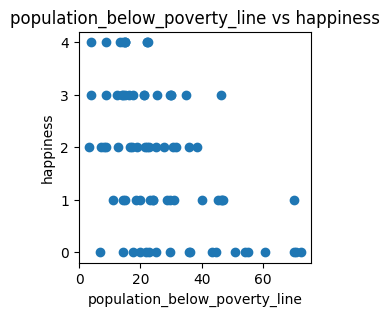

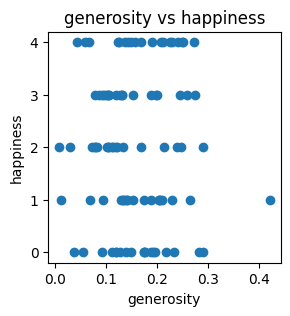

In [164]:
# LEO: scatter plots
# LEO: function for comparing multiple variables from X training
def x_scatter(a,b):
  plt.figure(figsize=(3,3))
  plt.scatter(X_train[a], X_train[b])
  plt.xlabel(f"{a}")
  plt.ylabel(f"{b}")
  plt.title(f'{a} vs {b}')
  plt.show()

# LEO: function for comparing X variable and Y variable
def y_scatter(a):
  plt.figure(figsize=(3,3))
  plt.scatter(X_train[a], y_train_labels)
  plt.title(f'{a} vs happiness')
  plt.xlabel(f"{a}")
  plt.ylabel(f"happiness")
  plt.show()


# LEO: bivariate scatter plot of gdp_per_capita vs. social_support
x_scatter("gdp_per_capita", "social_support")
x_scatter("gdp_per_capita","gni")
x_scatter("population_below_poverty_line","healthy_life_expectancy")
y_scatter("gdp_per_capita")
y_scatter("population_below_poverty_line")
y_scatter("generosity")

**LEO**: We notice a few things from the various scatter plots. We confirm the gdp_per_capita and social support relationship. We confirm the even stronger gdp_per_capita and gni relationship but interestingly learn that it is non linear (almost exactly exponential). We learn that population_below_poverty indeed has a negative correlation with healthy life expectancy. gdp_per_capita, and population_below_poverty line are plotted against happiness with slight relationships, but in opposite directions. generosity vs. happiness shows a minimal effect (as expected) on happiness. This reconfirms some findings from our correlation matrices in the previous step.

<Figure size 500x500 with 0 Axes>

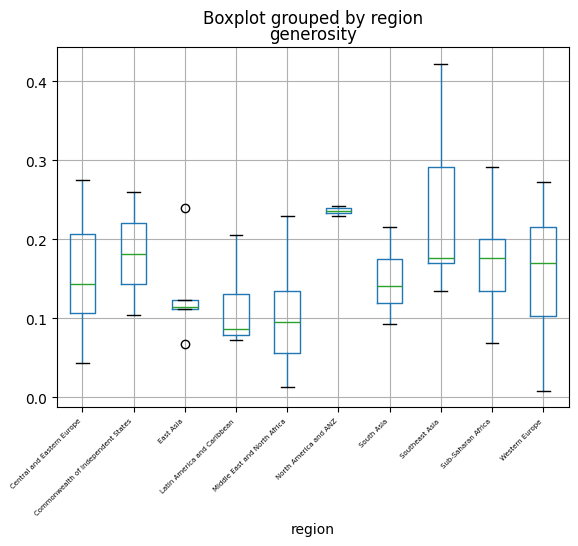

<Figure size 600x400 with 0 Axes>

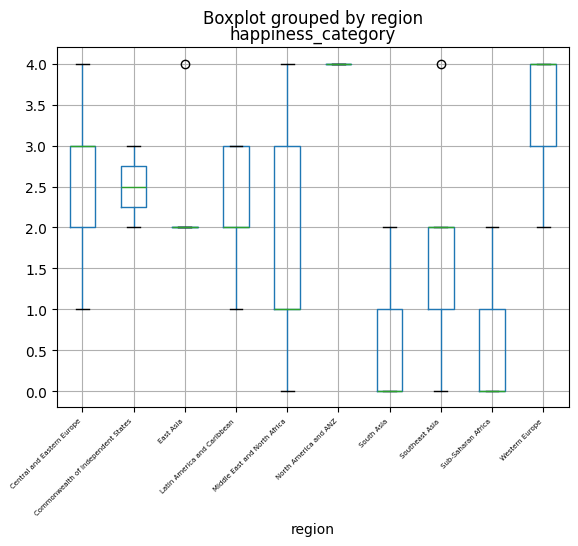

In [165]:
# LEO: box plots - we will do two box plots to save space here. We will show box plots for happiness by region.
def box_x(v1, v2):
    plt.figure(figsize=(5, 5))
    X_train.boxplot(column=v2, by=v1)
    plt.xticks(fontsize=5,rotation=45, ha='right') # right skew lines up with bars
    plt.show()

box_x("region","generosity")

def box_y(v1):
    plt.figure(figsize=(6, 4))
    # local object allows us to add y_train_labels values and create our chart
    local = X_train.copy()
    local['happiness_category'] = y_train_labels.values
    local.boxplot(column="happiness_category", by=v1)
    plt.xticks(fontsize=5,rotation=45, ha='right') # right skew lines up with bars
    plt.show()

box_y("region")

**LEO**: [Brief Discussion] Regional grouping seems to indicate that generosity is relevantly unrelated to the particular region of a country. Generosity is highest in southeast asia and african countries, but lowest in latin american countries. Generally, the spread is not too extreme between the means.

For happiness, there are clear winners and losers. North America and Western Europe display extremely high happiness, though perhaps for North America due to a limited amount of available countries (would have to be combined with testing data to get a better full picture). For South Asia and sub-saharan africa, happiness is consistently pretty low (by median).

We assume that by saying "e.g." that providing 2 out of the 3 suggested bivariate methods is sufficient for our exploration. We also feel that scatter plots and box plots by region provide more potential info/less scaling bias than multi-variable bar charts.

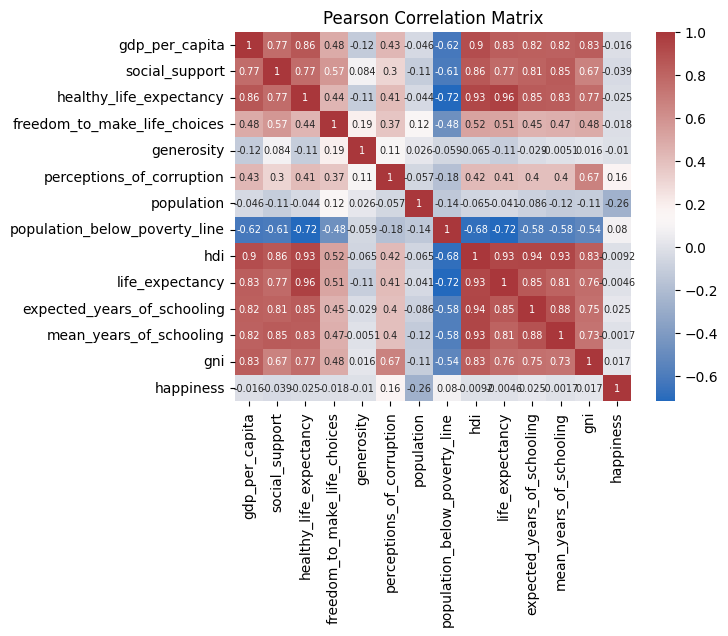

In [166]:
# LEO - correlation matrix - we now borrow our code from above to generate matrix including y data
locals = X_train.copy()
locals["happiness"] = y_train_labels
numerical_features_y = locals.select_dtypes(include="number").columns
matrix = locals[numerical_features_y].corr(method="pearson")
sns.heatmap(matrix, annot=True, cmap='vlag',annot_kws={'size': 7}) # we use matrix, annot for values, cmap for color specification, and annot to reduce text size
plt.title(f'Pearson Correlation Matrix')
plt.show()

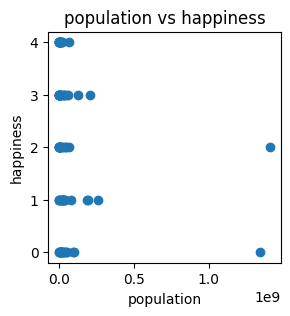

In [167]:
y_scatter("population")

In [168]:
X_train["population"].sort_values(ascending=False).head()

,population
92,1.409517e+09
20,1.339180e+09
46,2.639914e+08
39,2.092883e+08
77,1.970160e+08


We find something very interesting from the correlation matrix. Generally, the amount of correlation in our dataset is relatively low with the categorical variables. Intuitively, this makes sense (we have eliminated the continuity of our variables by grouping a continous variable into 5 categories).

What is more interesting is that when we plot our correlation matrix, population does have a significant negative correlation. The reason for this is actually not because of a real relationship. When we look at population on a y scatter, we see that there are two countries with population in the order of 1.3-1.4 billion, and the rest of the dataset countries in the training have a much smaller population (below 500 million). This means that these two countries (outliers) significantly impact the relationship we see. Good catch!

<Figure size 600x400 with 0 Axes>

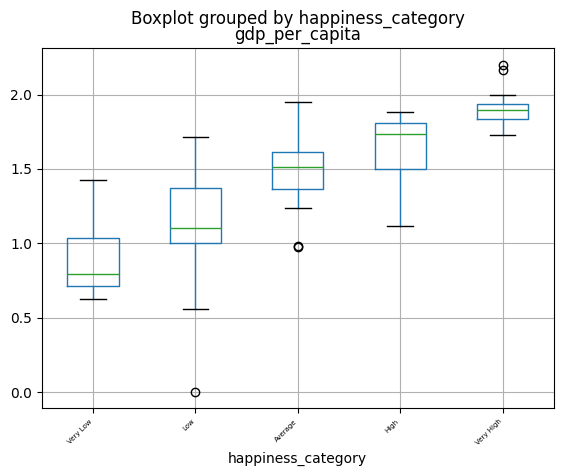

In [169]:
# LEO - box plots for categories of happiness compared to GDP per Capita lifting our code from above
plt.figure(figsize=(6, 4))
local2 = X_train.copy()
local2["happiness_category"] = y_train.values
local2.boxplot(column="gdp_per_capita", by="happiness_category")
plt.xticks(fontsize=5,rotation=45, ha="right") # right skew lines up with bars
plt.show()

**LEO**: [Brief Commentary] As we can see above, there is a general positive bump in gdp per capita as the happiness goes up. As mentioned before and shown through our box plot, this is to be expected with our macroeconomic background knowledge.

### Outlier Detection

Identify potential outliers in the numerical features using appropriate methods such as:

- Box plots
- Z-score analysis
- Interquartile Range (IQR) method

Highlight any significant anomalies and briefly comment on whether they should be retained, transformed, or removed.

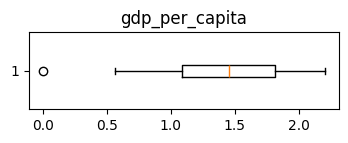

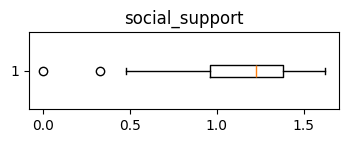

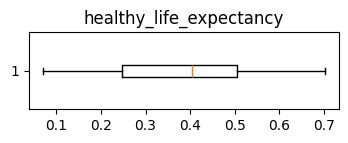

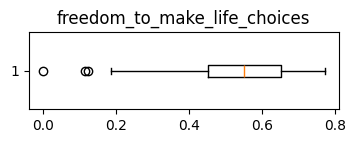

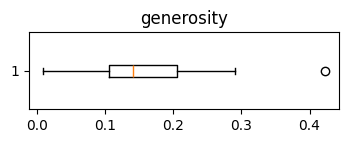

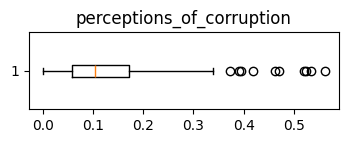

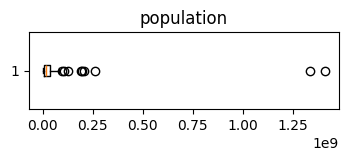

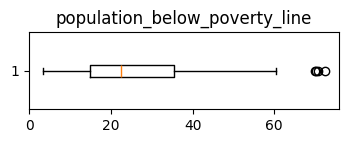

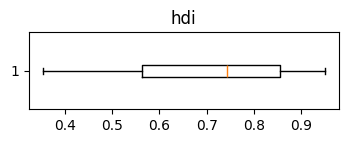

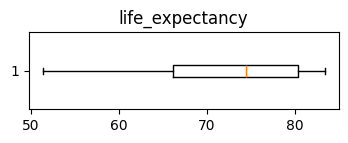

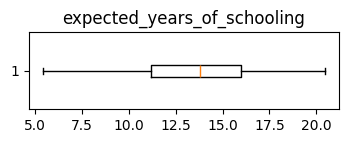

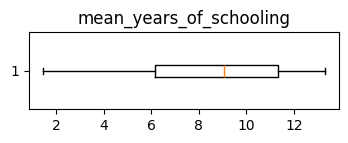

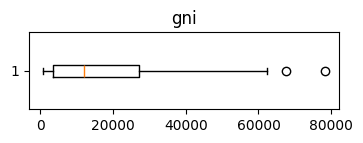

In [170]:
# LEO - the simplest way to find outliers is using for loop to create box plots.
for column_name in numerical_features_train:
    plt.figure(figsize=(4, 1))
    plt.boxplot(X_train[column_name].dropna(), vert = False, showfliers = True) # showfliers is critical so that we see dots for outliers (outside of normal IQR range)
    plt.title(column_name)
    plt.show()

**LEO** [brief comments] We can identify that gni, population_below_poverty_line, population, perceptions_of_corruption, generosity,freedom_to_make_life_choices,social_support, and gdp_per_capita have outliers. The most extreme outliers occur in perceptions of corruption, and population, and must be carefully addressed in our analysis.

### Observations and General Comments

Summarize your key findings from the exploratory analysis. Include:

- Important patterns or relationships identified
- Presence of missing values or outliers
- Potential feature engineering considerations
- Any preprocessing steps that should be applied before modeling

Keep your comments concise and evidence-based.

*Replace this section with your response.*

**LEO** [General Observations]

*Important patterns or relationships identified*

* gdp_per_capita is an important variable. Displays a positive relationship with our target (happiness), negative relationship with other income suggestive variables (such as population below poverty line), and has a pearson correlation above an absolute value of 0.4 for ALL but two variables.
* generosity, population, and categorical happiness have the lowest correlations with their peers. The low happiness correlation is deceptive because it is categorized from a continuous variable (which would likely have stronger correlations). We confirm this by plotting, for example, gdp per capita against happiness and seeing a positive relationship.
Also important to note that happiness and population are not actually correlated despite findings in the pearson correlation, but that this is due to excessive outliers in our data.
* We flag that gdp_per_capita and gni are similar measures of per capita economic state due to GNI's direct impact on GDP (and resultant gdp per capita). Multicollinearity may be at potential play here.
* Another similar pair is healthy_life_expectancy and life_expectancy which are as high as 0.96 (near exact correlation) because these variables are quite likely interlinked in their respective calculations.
* We are heavy in sub saharan africa and European countries, which makes sense based on the regional qualifications (north America has 3 countries in the space that Europe has 300 (double parentheses, we are exxagerating of course))

*Presence of missing values or outliers*

* We are missing values for 6-7% of most of our countries, but for one variable (population_below_poverty_line) we are missing 16% of values in our training dataset. We will be mindful of this when thinking about whether or not to include these values.
* There are outliers significantly outside of the range of their respective distributions in more than 5 variables in the x dataset, which we visualize successfully through box plot for loop for all variables. We find it most important to note that population has particularly egregious outliers and that corruption statistics also have very strong outliers.
* We also have some fundamentally skewed systems, for example - we know that social support is skewed heavily in the positive direction. As discussed above, regions are also skewed in some cases more towards particular areas. Life expectancy and gni are also heavily skewed.

*Potential feature engineering considerations / pre processing to apply before our model*
* We should certainly apply standard scaling, log transformations, and interactions as we are told to in steps 2 and 3. This will allow us to approach linear models successfully without bias (standard scaling, discussed later), mitigate outlier effects (log transformations), and harness how variables work together to impact our output (interaction terms)
* We also think that it would be effective to drop the variables that are almost identical. One is gni/gdp per capita, and we would prefer to keep gni given that it doesn't bake in non-population spending (which is less directly related to happiness). The other thing is to remove expected life expectancy and only operate based on true life expectancy, avoiding the multicollinearity that each of these near identical variable pairs can cause.


---

## 2. Feature Engineering

Apply log transformations to normalize skewed numerical features and improve model stability (if applicable).

In [171]:
print((X_train["gdp_per_capita"] < 0).sum())

0


In [172]:
# LEO - we select the columns with visible outliers in box plots to be scaled
import numpy as np # need numpy for log scaling
needs_fix = ["population", "gdp_per_capita", "social_support", "freedom_to_make_life_choices",
             "generosity","perceptions_of_corruption","population_below_poverty_line","gni"] # lot to be fixed!
for column_name in needs_fix:
  X_train[column_name] = np.log1p(X_train[column_name]) # we got a divide by zero warning and googled how to address that. log1p avoids the issue
  X_test[column_name] = np.log1p(X_test[column_name])

Create at least one interaction feature to capture relationships between existing variables and enhance predictive power.

In [173]:
# LEO - we are curious how social support from the government AND generosity improve the general mood and want to make an interaction with these
X_train["social_support_and_generosity"] = X_train["social_support"] * X_train["generosity"]
X_test["social_support_and_generosity"] = X_test["social_support"] * X_test["generosity"]
X_train["social_support_and_generosity"].head()

,social_support_and_generosity
0,0.093878
1,0.069369
2,0.195850
3,0.080145
4,0.201249


In [174]:
X_train.shape

(95, 17)

In [175]:
X_train.head()

,country,region,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni,social_support_and_generosity
0,Madagascar,Sub-Saharan Africa,0.489806,0.576051,0.178,0.171429,0.162969,0.125751,Madagascar,17.056965,4.272491,0.512149,65.515,10.34614,6.145955,7.185917,0.093878
1,Mauritania,Sub-Saharan Africa,0.741461,0.567584,0.244,0.277632,0.122218,0.178146,Mauritania,15.301692,3.465736,0.513106,63.239,8.46379,4.266000,8.168561,0.069369
2,Mongolia,East Asia,0.866680,0.913888,0.244,0.354172,0.214305,0.056380,Mongolia,14.939026,3.117950,0.734832,69.806,14.84552,9.750000,9.254377,0.195850
3,Tajikistan,Commonwealth of Independent States,0.679048,0.810041,0.291,0.469378,0.098940,0.256191,Tajikistan,16.003957,3.481240,0.627472,69.582,11.26186,10.355820,7.863876,0.080145
4,Ukraine,Central and Eastern Europe,0.857814,0.856116,0.355,0.438900,0.235072,0.015873,Ukraine,17.604754,3.222868,0.743049,71.129,15.30672,11.340000,8.904088,0.201249


---

## 3. Data Preprocessing

Use `sklearn`'s `ColumnTransformer` to preprocess the data. Write a preprocessing function and save the fitted preprocessor for later use.

In [176]:
# MAISY
# I added this cell because there were 10 categories that were one-hot encoded, which would give us 10 new features
# Instead, I grouped some features together to keep it down to 5 features
display("Regions before: \n", X_train['region'].value_counts())
conditions = {
    'Central and Eastern Europe': 'Europe',
    'Western Europe': 'Europe',
    'East Asia': 'Asia',
    'South Asia': 'Asia',
    'Southeast Asia': 'Asia',
    'Latin America and Caribbean': 'Others',
    'Commonwealth of Independent States': 'Others',
    'North America and ANZ': 'Others'
}
X_train['region'] = X_train['region'].replace(conditions)
X_test['region'] = X_test['region'].replace(conditions)

display("Regions after: \n:", X_train['region'].value_counts())

'Regions before: \n'

,count
region,
Sub-Saharan Africa,23
Central and Eastern Europe,17
Western Europe,16
Latin America and Caribbean,11
Middle East and North Africa,9
East Asia,5
South Asia,5
Southeast Asia,5
Commonwealth of Independent States,2


'Regions after: \n:'

,count
region,
Europe,33
Sub-Saharan Africa,23
Asia,15
Others,15
Middle East and North Africa,9


In [177]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ADDED - drop gdp_per_capita and health_life_expectancy from X_train and X_test
"""
X_train = X_train.drop(columns=['gdp_per_capita', 'healthy_life_expectancy'])
X_test = X_test.drop(columns=['gdp_per_capita', 'healthy_life_expectancy'])
"""
# removed, model performs better without the above lines

# Create the preprocessing pipelines for both numeric and categorical data.

numeric_features = X_train.select_dtypes(include='number') # same code as before ## Drop all the non-numerical features from X_train: TODO
numeric_features=numeric_features.columns.tolist()

numeric_transformer = Pipeline(steps=[
    # ('imputer', SimpleImputer(strategy='constant', fill_value=0)), ## Is this good enough?
    ('imputer', SimpleImputer(strategy='median')), # we change our strategy to median because the above assumes 0 is a good default
    ('scaler', StandardScaler())]) # You will need to describe why this is being done in the next cell

categorical_features = ['region'] #, 'sub-region'] ----- COMMENTED OUT BECAUSE WE HAVE NO SUB REGION

#Replacing missing values with Modal value and then one hot encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # most frequent is a modal approach
    ('onehot', OneHotEncoder(handle_unknown='ignore'))]) # not covered in recitation but found documentation that says smoothest operation is with 'ignore'

# final preprocessor object set up with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

#Fit your preprocessor object
preprocess=preprocessor.fit(X_train)

### Explanation

Briefly explain what the preprocessing steps above do and why they are needed.

If you changed the imputation strategy (or any other preprocessing choice), please state:

- What you changed
- Why you made that change

*Replace this section with your response.*

**LEO** [Brief Explanation]
* The numeric_features section of the code isolates numeric values so that we can apply standard scaling and data manipulation to them numerically and avoid confusion with our data.
* The numeric_transformer uses the Pipeline object to fill empty values with the median rather than 0. This is because median values are more akin to what our dataset might represent, rather than creating potential issues with values of 0 that are not correct.
* Afterwards, the StandardScaler defaults us to normal parameters of mean/SD of 0 and 1 for our numeric values. This allows us to avoid issues that are present with models requiring scaling (CNN for example). Otherwise, variables with larger SD or impact-heavy medians can have impacts on models. The other example is punishment-oriented regressions (that penalize SD or deviation) which require scaling to perform correctly.
* The categorical transformer fills in the most frequently occuring categorical variable for empty inputs and does one hot encoding, which converts categorical columns into numbers that can be understood by the model (e.g. networks cannot operate on "Sub Saharan Africa")
* The final pre processor setup coagulates the numeric and categorical transformations, and they are ultimately applied to X_train and stored in the preprocess object.
* I dropped "gdp_per_capita" and "healthy_life_expectancy" because they are nearly perfectly correlated with gni and life_expectancy (respectively). This avoids data redundancy, additional compute applied to effectively the same variables, and potential multicollinearity issues. **NOTE: WE ULTIMATELY ADDED THESE BACK BECAUSE THEY IMPROVE MODEL PERFORMANCE**

**MAISY/LEO**:
* As a post-operative point, we want to note that some of the models interestingly tend to perform slightly better with the variables that were dropped included. Wethink that this may be due to non-linear models not being affected by multicollinearity issues, but this is something we wanted to acknowledge despite it not being reflected in the coding output.

In [178]:
# function to transform data with preprocessor

def preprocessor(data):
    data = data.drop(['country', 'country_name'], axis=1) # had to make this correct because it was not actually dropping that
    preprocessed_data=preprocess.transform(data)
    return preprocessed_data

### Conceptual Question

Explain the differences between the following:

- The `preprocessor` **object**
- The `preprocess` **object**
- The `preprocessor` **function**
- The final `preprocessed_data` **returned**

Clearly distinguish between objects, functions, and transformed data.

*Replace this section with your response.*

**LEO:** [Explanation]

* Preprocessor object is the object that we created with the column transformer in the previous block of code. It has no data. It stores the transformations that we are applying to both our categorical and numeric variables, but it does not execute anything.
* Preprocessor function on the other hand is the function that is executed to transform our data (for preprocessing stage 3). This drops the categorical columns and then applies the preprocessor object parameters to some inputted data object for its function. it outputs our preprocessed_data object.
* That preprocessed_data object is just the output. It contains the data that has gone through all of the defined processes in the preprocessor object, meaning numericals are scaled, NAN values are treated, and categoricals are turned numerical. We use this to train our model.
* The preprocess object is what emerges after we fit our preprocessor object to our X data, meaning it has performed scaling and categorical encoding and ultimately executes transformations.

---

## 4. Model Training and Saving Artifacts

Fit the model on the preprocessed training data. Save the fitted preprocessor and the trained model for reuse (e.g., inference and submission).

In [179]:
# MAISY
# save the fitted preprocessor using joblib python library
import joblib
joblib.dump(preprocess, '/content/drive/MyDrive/preprocessor.joblib')

['/content/drive/MyDrive/preprocessor.joblib']

In [180]:
# MAISY
from sklearn.ensemble import RandomForestClassifier

scores = {}
X_train_preprocessed = preprocessor(X_train)
X_test_preprocessed = preprocessor(X_test)
print("Preprocessed X_train shape: ", X_train_preprocessed.shape)   # check to see if results match from above
print("Preprocessed X_test shape: ", X_test_preprocessed.shape)     # sanity check

model = RandomForestClassifier(random_state=165)

model.fit(X_train_preprocessed, y_train_labels)
model_score = model.score(X_test_preprocessed, y_test_labels)

print(f"Random Forest Model 1 Score: {round(model_score, 4)}")

Preprocessed X_train shape:  (95, 19)
Preprocessed X_test shape:  (42, 19)
Random Forest Model 1 Score: 0.5476


---

## 5. Model Evaluation

Generate predictions using `X_test`. Compare the predictions with the true labels in `y_test` using appropriate evaluation metrics.

In [181]:
# MAISY
y_predicted = model.predict(X_test_preprocessed)

Accuracy Score: 0.5476190476190477
Accuracy for 0: 44.44%
Accuracy for 1: 50.00%
Accuracy for 2: 50.00%
Accuracy for 3: 62.50%
Accuracy for 4: 66.67%


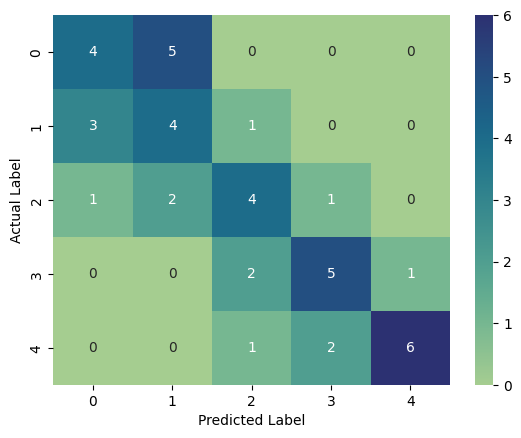

In [182]:
# MAISY
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
sns.color_palette('crest', as_cmap=True)

print(f"Accuracy Score: {accuracy_score(y_test_labels, y_predicted)}")

cm = confusion_matrix(y_test_labels, y_predicted)

sns.heatmap(cm, cmap='crest', annot=True)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label');

# This calculates the accuracies for each category. Since our data is multi-class
# classification, overall accuracy may not explain the true performance of the model
class_accuracies = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracies):
    print(f"Accuracy for {i}: {acc:.2%}")

In [183]:
# MAISY
print(round(precision_score(y_test_labels, y_predicted, average='weighted'), 4))
print(round(recall_score(y_test_labels, y_predicted, average='weighted'), 4))
print(round(f1_score(y_test_labels, y_predicted, average='weighted'), 4))

0.5744
0.5476
0.556


In [184]:
scores['RF_model1'] = [accuracy_score(y_test_labels, y_predicted), \
                       precision_score(y_test_labels, y_predicted, average='weighted'), \
                       recall_score(y_test_labels, y_predicted, average='weighted'), \
                       f1_score(y_test_labels, y_predicted, average='weighted')]

**[Explanation]**

The precision calculates the false positives compared to the true positives. (TP/(TP+FP))

The recall calculates the false negatives. (TP/(TP+FN))

And F1 score is the balance between the two. (2\*Precision\*Recall)/(Precision\*Recall)

As our target variables are multi-class, the calculation is slightly more complicated than a binary classification confusion matrix. Out of `macro`, `micro`, and `weighted`, I chose to look at `weighted` average of the score, which calculates the precision, recall, and F1 score for each class, and then weight it based on the number of occurrances for each class instead of averaging it out by the number of classes.

Weighted average is usually more common for an imbalanced dataset because it ensures that the larger class score does not overpower the imbalanced class, but in our case, even though our classes are quite balanced, it is still a safe bet to choose weighted average for each score instead of macro.

In [185]:
values = model.feature_importances_

feature_df = pd.DataFrame({'Feature': np.concatenate((numeric_features, np.arange(1,6,1))), 'Importance': values})
feature_df = feature_df.sort_values(by='Importance', ascending=False)
feature_df

,Feature,Importance
0,gdp_per_capita,0.106330
8,hdi,0.098193
1,social_support,0.098152
12,gni,0.086290
2,healthy_life_expectancy,0.083466
10,expected_years_of_schooling,0.070873
5,perceptions_of_corruption,0.067353
9,life_expectancy,0.066695
11,mean_years_of_schooling,0.062745
3,freedom_to_make_life_choices,0.057612


`feature_importances_` is a given function of the RandomForest model object that computes the feature importances of the dataset features.

From this, we can see that `hdi` has the highest feature importance to our target variable `happiness` and all of our region categories are ranked the lowest in terms of importance to `happiness`.

---

## 6. Hyperparameter Experimentation

Repeat the training and evaluation process with different model parameters to improve performance. Track results across experiments and report the best-performing configuration.

In [186]:
# Train model 2 using same preprocessor (note that you could save a new preprocessor, but we will use the same one for this example).
# MAISY
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(n_estimators=80, max_depth=10, criterion='log_loss', random_state=165)

model_2.fit(X_train_preprocessed, y_train_labels)
model_2_score = model_2.score(X_test_preprocessed, y_test_labels)

print(f"Random Forest Model 2 Score: {round(model_2_score, 4)}")

Random Forest Model 2 Score: 0.5238


### Reflection on Hyperparameter Changes

Briefly explain:

- What parameters you changed
- What each parameter controls
- Why the changes improved (or did not improve) performance

Support your explanation with evidence from your results.

**[Explanation]**

The first model built was a default model. For my second model, I chose to use such parameters because:
- `n_estimators=80`: From default of 100, I decreased it to 80. This parameter calculates the number of trees built for computation, however, the bigger the parameter, the bigger the computation cost. If there is no big difference in performance when greater number of trees, we would ideally want to save computational power.

- `max_depth=10`: The default of this parameter is `None`, which means that the tree does not stop branching until it is pure (or if there is a `min_samples_split` parameter set). Setting a cap to this would potentially avoid overfitting, as if there were no cap, it could branch to fit training set very well, leading to overfitting.

- `criterion='log_loss'`: Because it uses a logarithmic scale, it is much more sensitive to small changes in probabilities compared to the default method, gini.

In [187]:
# MAISY
prediction_labels = model_2.predict(X_test_preprocessed)
y_predicted_2 = model_2.predict(X_test_preprocessed)

Accuracy Score: 0.5238095238095238
Accuracy for 0: 44.44%
Accuracy for 1: 25.00%
Accuracy for 2: 62.50%
Accuracy for 3: 62.50%
Accuracy for 4: 66.67%


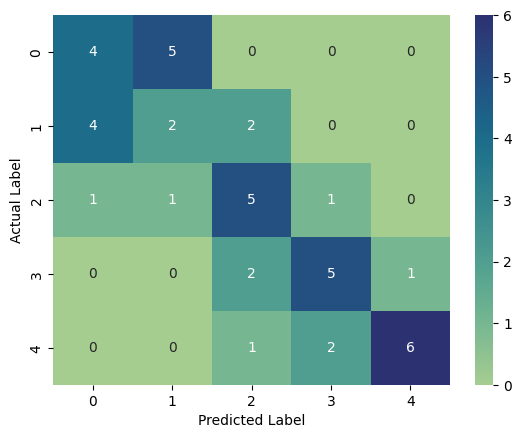

In [188]:
# MAISY
# Evaluation

print(f"Accuracy Score: {accuracy_score(y_test_labels, y_predicted_2)}")

cm = confusion_matrix(y_test_labels, y_predicted_2)

sns.heatmap(cm, cmap='crest', annot=True)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label');

class_accuracies = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracies):
    print(f"Accuracy for {i}: {acc:.2%}")

In [189]:
# MAISY
print(precision_score(y_test_labels, y_predicted_2, average='weighted'))
print(recall_score(y_test_labels, y_predicted_2, average='weighted'))
print(f1_score(y_test_labels, y_predicted_2, average='weighted'))

0.5408163265306123
0.5238095238095238
0.5284391534391534


In [190]:
scores['RF_model2'] = [accuracy_score(y_test_labels, y_predicted_2), \
                       precision_score(y_test_labels, y_predicted_2, average='weighted'), \
                       recall_score(y_test_labels, y_predicted_2, average='weighted'), \
                       f1_score(y_test_labels, y_predicted_2, average='weighted')]

### Discussion Question

Do you think it is worth making more changes to the parameters? Should we keep trying random values and see what works better? What is an alternative to doing this manually?

**[Explanation]**

I think it is worth making more changes to the parameters as there are many parameters in the RandomForestClassifier model, but because there are so many, doing it manually requires lots of time and effort. There is much room for the model to perform better, which is why we should make more changes to the parameters. In general, each machine learning project focuses on different aspects and problems where a certain combination may not be a fit for another project. The parameters are solely dependent on each project and its dataset, thus optimizing the model by making changes in the parameters are always necessary.

However, doing so manually would mean punching random values in each parameters, which is very inefficient. There are many hyperparamter tuning methods like GridSearchCV, RandomSearchCV, and more advanced methods and/or libraries like optuna or BayseianOptimization. However, just a GridSearch or RandomSearch would work perfectly fine for a simple model like our case.

In [198]:
# Submit a third model using GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# Use np.arange to create a sequence of numbers for each parameter's space you think should be searched: TODO
# Create a RandomForestClassifier object TODO
# Read GridSearchCV docs and create an object with RandomForestClassifier as the model TOD
# Fit the GridSearchCV object to the preprocessed training data: TODO

# MAISY
param_grid = {
    'n_estimators': np.arange(50, 250, 50),
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'log_loss']
}

model_3 = RandomForestClassifier(random_state=165)
gridmodel = GridSearchCV(model_3, param_grid)
gridmodel.fit(X_train_preprocessed, y_train_labels)

#extract best score and parameter by calling objects "best_score_" and "best_params_"
print("best mean cross-validation score: {:.3f}".format(gridmodel.best_score_))
print("best parameters: {}".format(gridmodel.best_params_))

best mean cross-validation score: 0.547
best parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': np.int64(50)}


Accuracy for 0: 44.44%
Accuracy for 1: 37.50%
Accuracy for 2: 37.50%
Accuracy for 3: 62.50%
Accuracy for 4: 66.67%


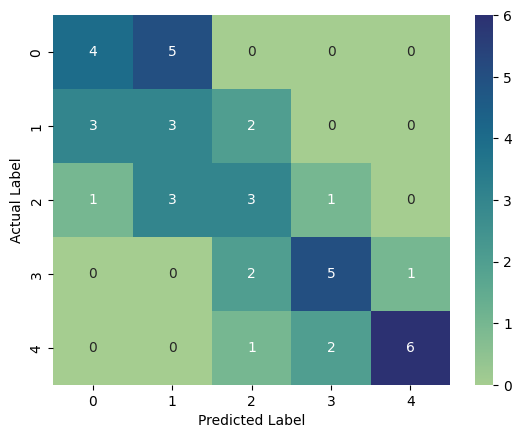

In [199]:
#Submit Model 3:
# MAISY
# Evaluation
y_predicted_3 = gridmodel.predict(X_test_preprocessed)
cm = confusion_matrix(y_test_labels, y_predicted_3)

sns.heatmap(cm, cmap='crest', annot=True)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label');

class_accuracies = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracies):
    print(f"Accuracy for {i}: {acc:.2%}")

In [200]:
# MAISY
print(precision_score(y_test_labels, y_predicted_3, average='weighted'))
print(recall_score(y_test_labels, y_predicted_3, average='weighted'))
print(f1_score(y_test_labels, y_predicted_3, average='weighted'))

0.5332405689548546
0.5
0.5121811882647795


In [201]:
scores['RF_model3'] = [accuracy_score(y_test_labels, y_predicted_3), \
                       precision_score(y_test_labels, y_predicted_3, average='weighted'), \
                       recall_score(y_test_labels, y_predicted_3, average='weighted'), \
                       f1_score(y_test_labels, y_predicted_3, average='weighted')]

In [202]:
# MAISY
# Here are several classic ML architectures you can consider choosing from to experiment with next:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier


## Read documentations of imported models and fit them. TODO
knn = KNeighborsClassifier()
knn.fit(X_train_preprocessed, y_train_labels)

knn_p = KNeighborsClassifier(n_neighbors=10, weights='distance')
knn_p.fit(X_train_preprocessed, y_train_labels)

print("Model Score for KNN: ", knn.score(X_test_preprocessed, y_test_labels))
print("Model Score for KNN w Params: ", knn_p.score(X_test_preprocessed, y_test_labels))

svc = SVC()
svc.fit(X_train_preprocessed, y_train_labels)

svc_p = SVC(gamma=0.15)
svc_p.fit(X_train_preprocessed, y_train_labels)

print("\nModel Score for SVC: ", svc.score(X_test_preprocessed, y_test_labels))
print("Model Score for SVC w Params: ", svc_p.score(X_test_preprocessed, y_test_labels))

gbm = GradientBoostingClassifier()
gbm.fit(X_train_preprocessed, y_train_labels)

gbm_p = GradientBoostingClassifier(n_iter_no_change=50, random_state=165)
gbm_p.fit(X_train_preprocessed, y_train_labels)

print("\nModel Score for GBM: ", gbm.score(X_test_preprocessed, y_test_labels))
print("Model Score for GBM w Params: ", gbm_p.score(X_test_preprocessed, y_test_labels))

Model Score for KNN:  0.5952380952380952
Model Score for KNN w Params:  0.5238095238095238

Model Score for SVC:  0.47619047619047616
Model Score for SVC w Params:  0.4523809523809524

Model Score for GBM:  0.38095238095238093
Model Score for GBM w Params:  0.40476190476190477


KNN Accuracy for 0: 44.44%
KNN Accuracy for 1: 25.00%
KNN Accuracy for 2: 75.00%
KNN Accuracy for 3: 50.00%
KNN Accuracy for 4: 66.67%


SVC Accuracy for 0: 44.44%
SVC Accuracy for 1: 50.00%
SVC Accuracy for 2: 50.00%
SVC Accuracy for 3: 37.50%
SVC Accuracy for 4: 44.44%


GBM Accuracy for 0: 44.44%
GBM Accuracy for 1: 12.50%
GBM Accuracy for 2: 25.00%
GBM Accuracy for 3: 50.00%
GBM Accuracy for 4: 66.67%




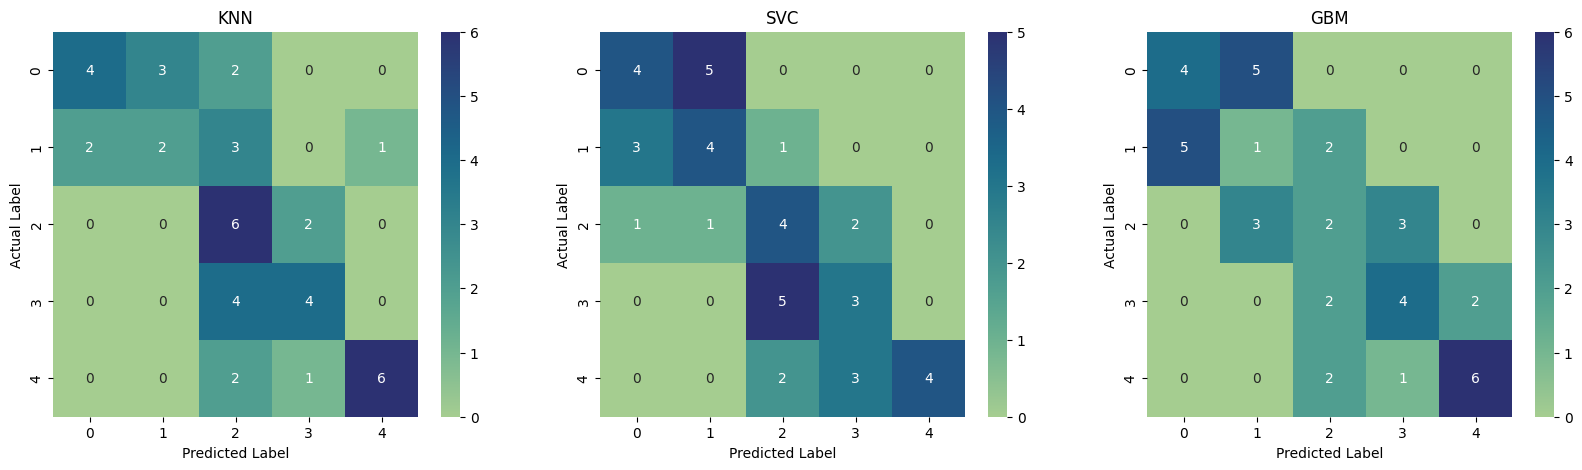

In [203]:
# MAISY
fig, axs = plt.subplots(1, 3, figsize=(20,5))

for i, a in zip(range(3), ['KNN', 'SVC', 'GBM']):
  if a == 'KNN':
    model = knn_p
  if a == 'SVC':
    model = svc_p
  if a == 'GBM':
    model = gbm_p
  y_predicted = model.predict(X_test_preprocessed)
  scores[a] = [accuracy_score(y_test_labels, y_predicted), \
               precision_score(y_test_labels, y_predicted, average='weighted'), \
               recall_score(y_test_labels, y_predicted, average='weighted'), \
               f1_score(y_test_labels, y_predicted, average='weighted')]

  cm = confusion_matrix(y_test_labels, y_predicted)
  axs[i].set_title(a)
  sns.heatmap(cm, cmap='crest', annot=True, ax=axs[i])
  axs[i].set_xlabel('Predicted Label')
  axs[i].set_ylabel('Actual Label')
  class_accuracies = cm.diagonal() / cm.sum(axis=1)

  for i, acc in enumerate(class_accuracies):
      print(f"{a} Accuracy for {i}: {acc:.2%}")
  print("\n")

In [204]:
scores_df = pd.DataFrame(scores).T
scores_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1']
scores_df

,Accuracy,Precision,Recall,F1
RF_model1,0.547619,0.574366,0.547619,0.556041
RF_model2,0.523810,0.540816,0.523810,0.528439
RF_model3,0.500000,0.533241,0.500000,0.512181
KNN,0.523810,0.578792,0.523810,0.526624
SVC,0.452381,0.532540,0.452381,0.464984
GBM,0.404762,0.419974,0.404762,0.411765


### Discussion Question

Describe the parameters you defined in `GradientBoostingClassifier`, and/or `BaggingClassifier`, and/or `KNN`, and/or `SVC`. What worked and why?

**[Explanation]**

For each three models I chose, `KNN`, `SVC`, and `GradientBoostingClassifier`, I trained and built one with default parameters and one with set parameters and chose higher performing model to use.

`KNN`:
- `n_neighbors=10` - The default value for this parameter is 5, which is how many nearest points you take into account when classifying the observing value. The range for this value is usually 3-15. When testing other numbers, 10 neighbors gave highest accuracy score showing that even with our small given sample, it is much better to take more neighboring data points into account when classifying happiness.
- `weights='distance'` - This parameter essentially gives the closer neighbors more weights when taking an average to classify. The default value is 'uniform' which means theres no weights to each neighbors when calculated. With our given small sample and higher number of neighbors, it is most likely better to give weights to the closer neighbors.

`SVC`:
- `gamma=0.15` - In SVC, the gamma parameter defines how far a data point influences. The default value is 'scale' which automatically adjusts based on the spread of the data but the model learned better when it was set to 0.15 which allows the model to account for local clusters without becoming too sensitive to individual noise. 0.15 is a moderate gamma which is not too low that the model is a flat line, but not too high that it isolates around every point.

`GradientBoostingClassifier`:
- `n_iter_no_change=50` - This parameter essentially sets the "early stopping" for the tree. The default value is set to None, which means that it will not stop. This was instead set to 50 to ensure it doesn't stop training prematurely due to minor, temporary fluctuations in the loss landscape. This is particularly useful for reaching the highest possible accuracy for a small dataset.

</br>

Most of the parameters worked since I randomly experimented each parameters of what works best. However, the problem with this was that there were high fluctuation in accuracy score even when changing the parameter values slightly where the lowest accuracy score was around 0.4. From our confusion matrix graphs for these 3 models and the RandomForest model before, we can see that class 0 and 1 has the worst accuracy where most traditional machine learning models confuse the two classes the most.

From the evaluation metrics, the KNN and RFM1 have almost the same metrics, showing that these two work best. It has the highest accuracy and almost similar F1 score, but RFM1 has slightly higher F1 score than that of KNN, which would be selected as the best performing model from the 3. RFM1 performs the best for our dataset on accuracy score.

---

## 7. Basic Deep Learning

In [205]:
# Now experiment with deep learning models:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.utils import to_categorical
import numpy as np

# Siyi
# Preprocess input features:
X_train_preprocessed = preprocessor(X_train)
X_test_preprocessed = preprocessor(X_test)

feature_count = X_train_preprocessed.shape[1] #count features in input data

# Determine the number of classes for the output layer
num_classes = len(np.unique(y_train_labels))

keras_model = Sequential([
    Dense(128, input_dim=feature_count, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax') # Last layer neurons should be equal to the number of unique classes
])

# Encode categorical labels
y_train_one_hot = to_categorical(y_train_labels, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test_labels, num_classes=num_classes)

# Compile model
keras_model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Fitting the NN to the Training set
history = keras_model.fit(X_train_preprocessed, y_train_one_hot, ## Note that keras models require a one-hot-encoded y_train object
               batch_size = 20,
               epochs = 300, validation_split=0.25)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.2933 - loss: 1.6569 - val_accuracy: 0.2083 - val_loss: 1.5953
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3196 - loss: 1.6363 - val_accuracy: 0.2917 - val_loss: 1.5893
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3692 - loss: 1.6084 - val_accuracy: 0.2500 - val_loss: 1.5840
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3802 - loss: 1.5840 - val_accuracy: 0.2500 - val_loss: 1.5792
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3135 - loss: 1.5885 - val_accuracy: 0.2083 - val_loss: 1.5757
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3039 - loss: 1.5729 - val_accuracy: 0.1667 - val_loss: 1.5714
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3123 - loss: 1.5517 - val_accuracy: 0.1250 - val_loss: 1.5674
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2873 - loss: 1.5549 - val_accuracy: 0.1250 - val_loss: 1.5630
Epo

### Discussion Question

Which activation functions did you use in the hidden layers? Why was **softmax** used in the final layer?

**Siyi:**

1.  **Hidden Layers (Dense(128), Dense(64), Dense(64), Dense(32))**: These layers all use the **ReLU (Rectified Linear Unit)** activation function.

    *   **Why ReLU?**: ReLU is a popular choice for hidden layers in neural networks because it introduces non-linearity, allowing the model to learn complex relationships in the data. It's computationally efficient and helps prevent the vanishing gradient problem, which can hinder the training of deep networks.

2.  **Final Layer (Dense(num_classes))**: This layer uses the **Softmax** activation function.

    *   **Why Softmax?**: Softmax is used in the final layer because our problem is a **multi-class classification** task (predicting one of five happiness categories). Softmax takes the raw output scores from the neural network and converts them into a probability distribution over the `num_classes` possible output classes. The output of the softmax function will be a set of probabilities that sum to 1, where each probability represents the likelihood that the input belongs to a specific class.

### Discussion Question

Was it a good idea to train for 300 epochs? Should you train longer? Why or why not?

**Siyi:**

Training for 300 epochs might be excessive or just right, depending on the model's learning curve. Here's a breakdown:

*   **Too Few Epochs (Underfitting)**: If the model doesn't train for enough epochs, it might not learn the underlying patterns in the data sufficiently. This is called underfitting, and both training and validation performance would typically be low.

*   **Optimal Epochs**: Ideally, we want to train the model until its performance on the validation set (or test set) stops improving or begins to degrade. This point represents a good balance between learning the training data and generalizing to unseen data.

*   **Too Many Epochs (Overfitting)**: Training for too many epochs can lead to overfitting. In this scenario, the model learns the training data too well, including its noise and specific quirks, but performs poorly on new, unseen data. We would observe training loss continuing to decrease, but validation loss starting to increase.

**To determine if 300 epochs was optimal, or if we should train longer, we need to inspect the `history` object returned by `keras_model.fit`.** This object contains the loss and accuracy metrics for both the training and validation sets across all epochs. By plotting these metrics, we can comment on the amount of Epochs:
* It seems that we begin to plateau above 90% accuracy around the 200-mark of the epochs, meaning that **300 epochs is likely excessive and leading to potential overfitting of the model**

### Discussion Question

Why was `loss='categorical_crossentropy'` and `optimizer='sgd'` used? Would you change anything? Why or why not?

**Siyi:**

1.  **`loss='categorical_crossentropy'`**: This loss function is appropriate because our task is a **multi-class classification problem**, and our target labels (`y_train_one_hot`, `y_test_one_hot`) have been **one-hot encoded**. Categorical cross-entropy measures the performance of a classification model whose output is a probability value between 0 and 1. It compares the distribution of the true labels with the predicted probability distribution of the model.

2.  **`optimizer='sgd'` (Stochastic Gradient Descent)**: SGD is a fundamental and widely used optimization algorithm for training neural networks. It works by updating the model's weights after processing a small batch of training examples, rather than the entire dataset. This makes it computationally efficient, especially for large datasets. It also introduces some randomness, which can help escape local minima in the loss landscape.

**Would I change anything? Why or why not?**

*   **Loss Function**: For this specific problem (multi-class classification with one-hot encoded labels), `categorical_crossentropy` is the correct and most commonly used loss function. Therefore, I would **not change** the loss function.

*   **Optimizer**: While `sgd` is a good baseline, it can sometimes be slow to converge and may require careful tuning of the learning rate. I would definitely **consider changing** the optimizer to more advanced adaptive learning rate optimizers, such as:
    *   **Adam (Adaptive Moment Estimation)**: This is often considered the default choice for many deep learning tasks due to its efficiency and good performance across a wide range of problems. It combines the benefits of RMSprop and Adagrad.
    *   **RMSprop (Root Mean Square Propagation)**: This optimizer adapts the learning rate for each parameter, which helps when dealing with sparse gradients or non-stationary objectives.

    Experimenting with these optimizers could lead to faster convergence and potentially better overall model performance, as they often require less manual tuning of the learning rate and can navigate complex loss landscapes more effectively.

### Plot Training Curves

Extract the model training history and plot the learning curves (e.g., training vs. validation loss and accuracy) across epochs.

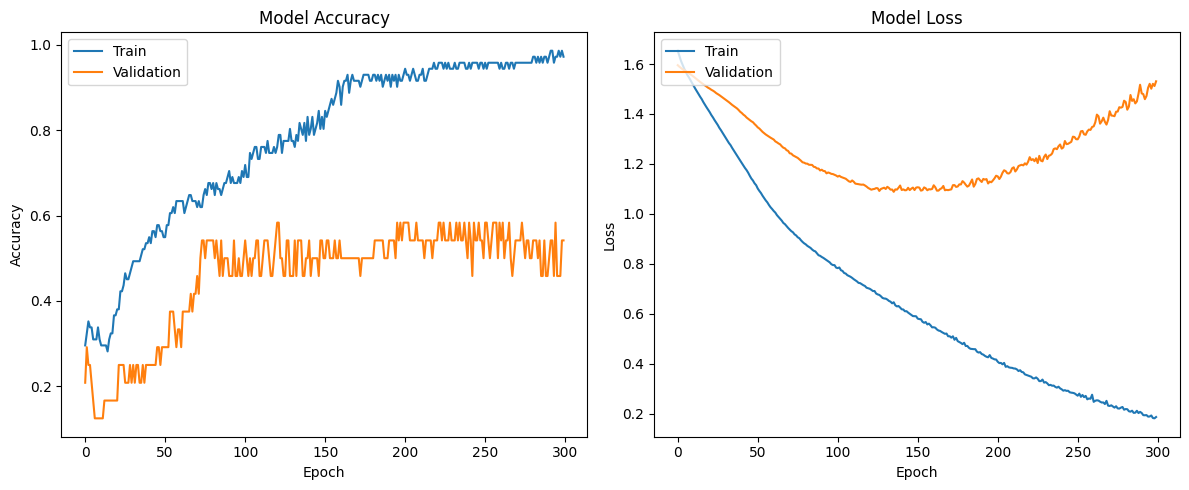

In [206]:
## Your code to plot training and validation curves in a single plot (Make changes in the model cell to be able to do this) : TODO
# Siyi

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # One row, two columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # One row, two columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Deep Learning Model Accuracy Score: 0.5000


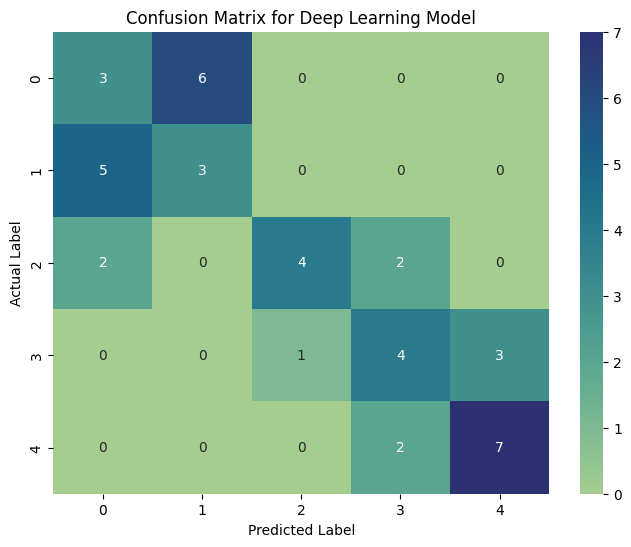

Accuracy for class 0: 33.33%
Accuracy for class 1: 37.50%
Accuracy for class 2: 50.00%
Accuracy for class 3: 50.00%
Accuracy for class 4: 77.78%


In [209]:
#-- Generate predicted y values

# Siyi
# Note: Keras predict returns the predicted column index location for classification models
prediction_column_index = keras_model.predict(X_test_preprocessed)
prediction_labels = np.argmax(prediction_column_index, axis=1)

# extract correct prediction labels
# The prediction_labels directly represent the numerical class indices, matching y_test_labels

## Write lines of code to show model performance by comparing prediction_labels with true labels:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Deep Learning Model Accuracy Score: {accuracy_score(y_test_labels, prediction_labels):.4f}")

cm_keras = confusion_matrix(y_test_labels, prediction_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='crest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Deep Learning Model')
plt.show()

class_accuracies_keras = cm_keras.diagonal() / cm_keras.sum(axis=1)

for i, acc in enumerate(class_accuracies_keras):
    print(f"Accuracy for class {i}: {acc:.2%}")

### Regularization: Dropout and Batch Normalization

Implement regularization techniques such as **Dropout** and **Batch Normalization** to improve generalization and observe the change in performance.

> **Note:** Compare training vs. test (or validation) loss and accuracy before and after adding regularization.

In [208]:
# Write your lines of code here:
# Siyi

from keras.layers import Dropout, BatchNormalization

keras_model_reg = Sequential([
    Dense(128, input_dim=feature_count),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(32),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile model
keras_model_reg.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Fitting the NN to the Training set
history_reg = keras_model_reg.fit(X_train_preprocessed, y_train_one_hot,
               batch_size = 20,
               epochs = 300, validation_split=0.25)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.2535 - loss: 2.0666 - val_accuracy: 0.2917 - val_loss: 1.6087
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1782 - loss: 2.0558 - val_accuracy: 0.2917 - val_loss: 1.6069
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2743 - loss: 1.8840 - val_accuracy: 0.3333 - val_loss: 1.6066
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2560 - loss: 1.9269 - val_accuracy: 0.3750 - val_loss: 1.6064
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2850 - loss: 1.7293 - val_accuracy: 0.3333 - val_loss: 1.6049
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1163 - loss: 2.0566 - val_accuracy: 0.2917 - val_loss: 1.6006
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2897 - loss: 1.6648 - val_accuracy: 0.2917 - val_loss: 1.5945
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1912 - loss: 1.8652 - val_accuracy: 0.3750 - val_loss

### Activation Function Experimentation

Experiment with different activation functions — **ReLU**, **LeakyReLU**, **Tanh**, and **Sigmoid** — and compare their impact on model performance.

In [214]:
# Your lines of code here
# LEO

deepscores = {}

for idx, name in enumerate(['relu', 'sigmoid', 'tanh']):
  model = Sequential([
      Dense(128, input_dim=feature_count),
      BatchNormalization(),
      Activation(name),
      Dropout(0.3),
      Dense(64),
      BatchNormalization(),
      Activation(name),
      Dropout(0.3),
      Dense(64),
      BatchNormalization(),
      Activation(name),
      Dropout(0.3),
      Dense(32),
      BatchNormalization(),
      Activation(name),
      Dropout(0.3),
      Dense(num_classes, activation='softmax')
  ])


  model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
  model.fit(X_train_preprocessed, y_train_one_hot, batch_size=20, epochs=300)

  modelpredicts = model.predict(X_test_preprocessed, verbose=0)
  prediction_labels = modelpredicts.argmax(axis=1)
  acc = accuracy_score(y_test_labels, prediction_labels)
  print(f"Model {name} Accuracy Score: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1757 - loss: 1.9451
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1499 - loss: 2.0118
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1672 - loss: 2.0644
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1603 - loss: 1.9661
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2550 - loss: 1.6157
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2029 - loss: 1.7958
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1073 - loss: 1.9223
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3017 - loss: 1.6920
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2891 - loss: 1.6842
Epoch 10/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2807 - loss: 1.8114
Epoch 11/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2062 - loss: 1.6922
Epoch 12/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2752 - lo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1673 - loss: 2.0232
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1471 - loss: 1.9402 
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1757 - loss: 1.9286 
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2466 - loss: 1.7345 
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1895 - loss: 1.8228
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1951 - loss: 1.7781
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1666 - loss: 1.7798
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2709 - loss: 1.7644
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1772 - loss: 1.7392 
Epoch 10/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2668 - loss: 1.7400
Epoch 11/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2479 - loss: 1.7355
Epoch 12/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1687 - loss: 1.7459
Ep

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2188 - loss: 1.9821
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2495 - loss: 1.7549 
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2797 - loss: 1.6670
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3652 - loss: 1.6087 
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3478 - loss: 1.4402 
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4167 - loss: 1.3170 
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4216 - loss: 1.4127
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4145 - loss: 1.4305
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4216 - loss: 1.3416 
Epoch 10/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5170 - loss: 1.3620
Epoch 11/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4863 - loss: 1.3521 
Epoch 12/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3144 - loss: 1.5925
Ep

It seems that sigmoid performs the best out of all of these 3 models on testing performance, but extremely poorly with training data. Relu is a close second place on testing data with much better training data. let's compare sigmoid to leakyrelu.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 404ms/step - accuracy: 0.1576 - loss: 2.2478 - val_accuracy: 0.3333 - val_loss: 1.6087
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.1413 - loss: 2.1324 - val_accuracy: 0.2917 - val_loss: 1.6041
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1480 - loss: 2.0645 - val_accuracy: 0.2500 - val_loss: 1.6022
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.1959 - loss: 1.8979 - val_accuracy: 0.2083 - val_loss: 1.6002
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.2381 - loss: 1.9041 - val_accuracy: 0.2500 - val_loss: 1.5979
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.1878 - loss: 1.7677 - val_accuracy: 0.2500 - val_loss: 1.5930
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1636 - loss: 1.6609 - val_accuracy: 0.2500 - val_loss: 1.5865
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2016 - loss: 1.8833 - val_accuracy: 0.2917 - val_lo

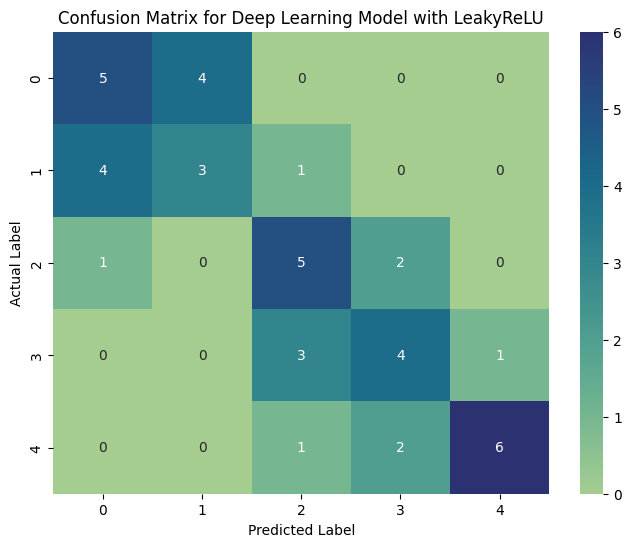

Accuracy for class 0 (LeakyReLU): 55.56%
Accuracy for class 1 (LeakyReLU): 37.50%
Accuracy for class 2 (LeakyReLU): 62.50%
Accuracy for class 3 (LeakyReLU): 50.00%
Accuracy for class 4 (LeakyReLU): 66.67%


In [213]:
# Your lines of code here
# Siyi

from keras.layers import LeakyReLU

# Model with LeakyReLU activation
keras_model_leaky_relu = Sequential([
    Dense(128, input_dim=feature_count),
    BatchNormalization(),
    LeakyReLU(alpha=0.01), # Using LeakyReLU
    Dropout(0.3),
    Dense(64),
    BatchNormalization(),
    LeakyReLU(alpha=0.01), # Using LeakyReLU
    Dropout(0.3),
    Dense(64),
    BatchNormalization(),
    LeakyReLU(alpha=0.01), # Using LeakyReLU
    Dropout(0.3),
    Dense(32),
    BatchNormalization(),
    LeakyReLU(alpha=0.01), # Using LeakyReLU
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile model
keras_model_leaky_relu.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Fitting the NN to the Training set
history_leaky_relu = keras_model_leaky_relu.fit(X_train_preprocessed, y_train_one_hot,
               batch_size = 20,
               epochs = 300, validation_split=0.25)

print("\n--- Evaluating LeakyReLU Model ---")
# Generate predictions
prediction_column_index_leaky_relu = keras_model_leaky_relu.predict(X_test_preprocessed)
prediction_labels_leaky_relu = np.argmax(prediction_column_index_leaky_relu, axis=1)

# Evaluate performance
accuracy_leaky_relu = accuracy_score(y_test_labels, prediction_labels_leaky_relu)
print(f"Deep Learning Model with LeakyReLU Accuracy Score: {accuracy_leaky_relu:.4f}")

cm_leaky_relu = confusion_matrix(y_test_labels, prediction_labels_leaky_relu)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_leaky_relu, annot=True, fmt='d', cmap='crest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Deep Learning Model with LeakyReLU')
plt.show()

class_accuracies_leaky_relu = cm_leaky_relu.diagonal() / cm_leaky_relu.sum(axis=1)

for i, acc in enumerate(class_accuracies_leaky_relu):
    print(f"Accuracy for class {i} (LeakyReLU): {acc:.2%}")

Under 300 epochs, this seems to perform the best.

---

## 8. Explainability – SHAP Feature Importance

To better understand the model's predictions, we will use **SHAP (SHapley Additive exPlanations)** to analyze feature importance.

**How SHAP works:**

- SHAP assigns each feature a contribution score for every prediction.
- It uses Shapley values (from cooperative game theory) to fairly distribute importance across features.

We will apply SHAP to visualize and interpret the model's feature contributions.

PermutationExplainer explainer: 43it [00:16,  1.73it/s]
/tmp/ipykernel_481/2316774746.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_preprocessed, feature_names=all_feature_names)


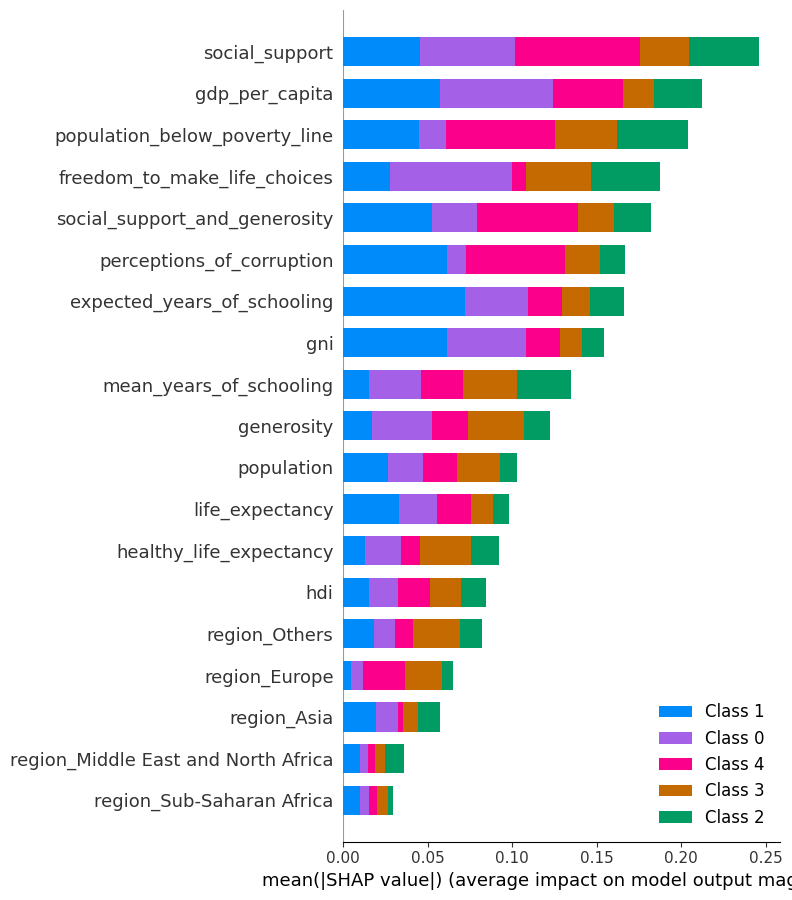

In [ ]:
# Import necessary libraries
import shap
import matplotlib.pyplot as plt

# Siyi

# Initialize SHAP explainer:
# Define an explainer that will help us interpret the model's decisions
# (Using shap.Explainer with the trained Keras model and X_test_preprocessed data)
explainer = shap.Explainer(keras_model, X_train_preprocessed)

# Compute SHAP values for X_test
# This step generates Shapley values, which explain how each feature contributes to predictions
shap_values = explainer(X_test_preprocessed)

# Generate generic feature names matching the number of columns after preprocessing
# Get numerical feature names (from the modified numeric_features list)
# Need to ensure the `numeric_features` list reflects the columns after dropping and adding
current_numeric_features = [
    'social_support', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption',
    'population', 'population_below_poverty_line', 'hdi', 'life_expectancy',
    'expected_years_of_schooling', 'mean_years_of_schooling', 'gni',
    'social_support_and_generosity', "gdp_per_capita","healthy_life_expectancy"
]

# Get categorical feature names after one-hot encoding
categorical_feature_names_out = preprocess.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

# Combine all feature names
all_feature_names = current_numeric_features + list(categorical_feature_names_out)

# Generate SHAP summary plot
# This plot will show which features have the most impact on predictions
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=all_feature_names)

# The cell should output a SHAP summary plot showing the most important features.

### Experimentation

In [ ]:
## You are encouraged to try more experimentation and any other models by adding more code cells to this notebook:

## You can also try to import any new dataset pertaining to countries, merge it, and see if it helps the predictions.
## If it does not, try to explain why it wasn't helpful by exploring variable relationships.

Deep learning models are often considered "black boxes" due to their complexity. Use SHAP to explain your model's predictions.

After applying SHAP, discuss:

- Does it provide a clear and sufficient explanation of how the model makes decisions?
- How easy or difficult is it to justify your model's predictions using this technique?

PermutationExplainer explainer: 43it [00:10,  2.19s/it]


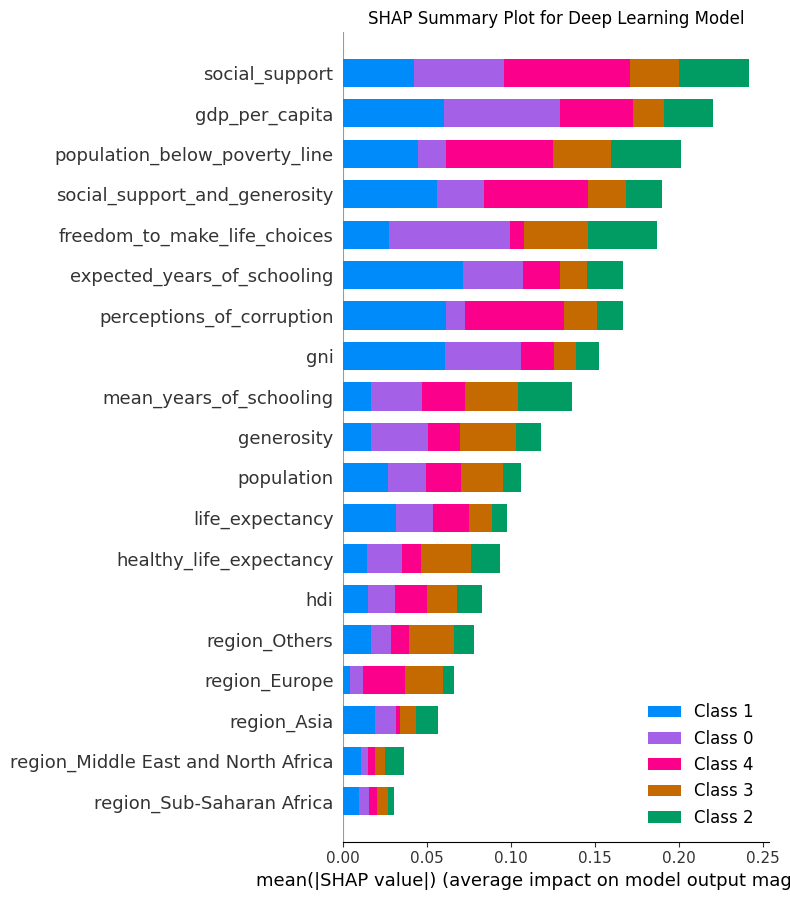

In [ ]:
## Your lines of Code and Answer:

# Siyi
# Import necessary libraries for SHAP plotting
import shap
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Assuming `keras_model` is the final or best-performing DL model from previous steps
# Assuming `X_train_preprocessed` and `X_test_preprocessed` are the preprocessed data
# Assuming `categorical_features` and `preprocess` (fitted ColumnTransformer) are available

# Initialize SHAP explainer using the trained deep learning model and preprocessed training data
explainer = shap.Explainer(keras_model, X_train_preprocessed)

# Compute SHAP values for the preprocessed test data
shap_values = explainer(X_test_preprocessed)

# Generate feature names to match the columns after preprocessing
# These lists were created in previous cells but are recreated here for self-containment if needed
current_numeric_features = [
    'social_support', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption',
    'population', 'population_below_poverty_line', 'hdi', 'life_expectancy',
    'expected_years_of_schooling', 'mean_years_of_schooling', 'gni',
    'social_support_and_generosity','gdp_per_capita','healthy_life_expectancy'
]
categorical_feature_names_out = preprocess.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = current_numeric_features + list(categorical_feature_names_out)

# Generate SHAP summary plot
plt.figure(figsize=(10, 8))
np.random.seed(42) # For reproducibility with SHAP

# Temporarily ignore FutureWarning for the shap.summary_plot call
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    shap.summary_plot(shap_values, X_test_preprocessed, feature_names=all_feature_names, show=False)

plt.title('SHAP Summary Plot for Deep Learning Model')
plt.tight_layout()
plt.show()

**Siyi:**

### SHAP Analysis of Deep Learning Model Explainability

**1. Does it provide a clear and sufficient explanation of how the model makes decisions?**

Yes, SHAP provides a generally clear and sufficient explanation of how the deep learning model makes decisions, especially at a global feature importance level. The SHAP summary plot effectively visualizes which features are most influential across the entire dataset and indicates the direction of their impact (positive or negative correlation) on the model's output. For example, by observing the plot, one can quickly discern that higher values of certain features (e.g., `hdi`, `gni`, `social_support`) tend to push the model's prediction towards higher happiness categories, while lower values push it towards lower categories.

However, the 'sufficiency' can depend on the audience and the depth of explanation required. While it clearly shows feature contributions, it doesn't reveal the intricate non-linear transformations happening within each neuron or layer of the deep neural network. For someone seeking to understand the exact mathematical operations at every step, SHAP provides a higher-level, aggregated view rather than a complete algorithmic breakdown.

**2. How easy or difficult is it to justify your model's predictions using this technique?**

Justifying the deep learning model's predictions using SHAP is **relatively easy**, particularly for a non-technical audience or for understanding overall model behavior. The visual nature of SHAP plots (like the summary plot) makes it intuitive to grasp which factors are driving predictions. For instance:

*   **Global Explanations:** The summary plot allows for a straightforward discussion about the most important features across all predictions, providing a general understanding of the model's biases and focus areas.
*   **Local Explanations (Individual Predictions):** While not explicitly generated here, SHAP's force plots or waterfall plots can be used to explain *why* a single country received a specific happiness prediction. These plots show how each feature value for that particular instance contributes additively to the final prediction, making it possible to provide a transparent 'story' for each output. This ability to explain individual predictions is crucial for building trust and accountability in AI systems.

Compared to trying to interpret raw weights in a complex neural network or deciphering the internal logic of an ensemble model without such tools, SHAP significantly simplifies the justification process. It translates complex model outputs into an interpretable language of feature contributions, making the model more auditable and understandable.

---

## 9. Final Report Submission (GitHub)

This is your final project to showcase on GitHub.

### Instructions

1. Create a new notebook for the final report.
2. Include relevant visualizations.
3. Reproduce the code for the best-performing model(s) and display results.
4. Summarize key insights and observed behaviors.
5. Present the work in a clean, concise report format (within the `.ipynb`).
6. Upload the final notebook to a new repository on your personal GitHub account.
7. Paste the link to your final repository at the top of this notebook where requested.